# 03. Acid Oxygen Reduction Reaction

The acid associative 4-electron oxygen reduction reaction comprises five
elementary steps: a chemical O$_2$ adsorption followed by four proton-coupled
electron transfers. With additional electrons transferred upstream of the RLS,
the classical analysis predicts a series of cardinal slopes. The three methods are applied to the mechanism, and the paper's designed rate-limiting-step (RLS) cases are constructed: parameter sets that share identical thermodynamics
($\prod_i K_i = 1$, so every case has the same equilibrium potential) and
differ only in which elementary step is kinetically slow. Comparing their Tafel
responses isolates the kinetic contribution to the slope.

The notebook is run from the repository's `tutorials/` folder so that the
imports resolve. `numpy`, `scipy`, and `matplotlib` are required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import core
import mechanisms as M

## The mechanism

$$1.\;\mathrm{M}+\mathrm{O_2}\rightleftharpoons \mathrm{MOO}\;\;\text{(ChemAds, chemical)}$$
$$2.\;\mathrm{MOO}+\mathrm{H_3O^+}+e^-\rightleftharpoons \mathrm{MOOH}\;\;\text{(PCET1)}$$
$$3.\;\mathrm{MOOH}+\mathrm{H_3O^+}+e^-\rightleftharpoons \mathrm{MO}\;\;\text{(PCET2)}$$
$$4.\;\mathrm{MO}+\mathrm{H_3O^+}+e^-\rightleftharpoons \mathrm{MOH}\;\;\text{(PCET3)}$$
$$5.\;\mathrm{MOH}+\mathrm{H_3O^+}+e^-\rightleftharpoons \mathrm{M}\;\;\text{(PCET4)}$$

Overall $\mathrm{O_2}+4\,\mathrm{H_3O^+}+4e^-\rightleftharpoons 6\,\mathrm{H_2O}$;
cathodic (`direction=-1`), unit activities. `M.orr_case(rls)` constructs the
paper's case for a chosen RLS: steps upstream of the RLS are made uphill
($K=0.01$) so that the RLS reactant remains unsaturated near onset, downstream
steps are thermodynamically constrained so that $\prod K_i = 1$, and the RLS forward constant
is slow. Every non-RLS step is
additionally accelerated by $10^5$ (forward and backward together, leaving all
$K_i$ unchanged) so that the named step remains the unique bottleneck across
the full scan. The methods walkthrough uses the PCET2 case without this
acceleration (`fast=1.0`), which keeps the stochastic method efficient.

In [2]:
mech = M.orr_case("PCET2", fast=1.0)
print("species:", mech.species)
print("steps:  ", mech.labels)

species: ['M', 'MOO', 'MOOH', 'MO', 'MOH']
steps:   ['ChemAds', 'PCET1', 'PCET2', 'PCET3', 'PCET4']


## Numerical integration to steady state

The coverage equations are integrated from a clean surface until they reach steady-state.


In [3]:
etas_coarse = np.linspace(-0.004, -0.55, 12)
eta_n, j_n, th_n, b_n = core.numerical_scan(mech, etas_coarse)

print(f"{'eta/V':>8}{'j/A cm^-2':>14}{'b/mV dec^-1':>13}   coverages")
for e, jj, th, b in zip(eta_n, j_n, th_n, b_n):
    cov = "  ".join(f"{s}={t:6.3f}" for s, t in zip(mech.species, th))
    print(f"{e:8.3f}{jj:14.3e}{b:13.1f}   {cov}")

   eta/V     j/A cm^-2  b/mV dec^-1   coverages
  -0.004    -2.216e-11         11.0   M= 0.982  MOO= 0.010  MOOH= 0.000  MO= 0.000  MOH= 0.008
  -0.054    -8.731e-10         39.4   M= 0.988  MOO= 0.010  MOOH= 0.001  MO= 0.000  MOH= 0.001
  -0.103    -1.577e-08         39.6   M= 0.984  MOO= 0.010  MOOH= 0.005  MO= 0.000  MOH= 0.000
  -0.153    -2.761e-07         40.6   M= 0.954  MOO= 0.010  MOOH= 0.036  MO= 0.000  MOH= 0.000
  -0.203    -4.006e-06         46.9   M= 0.790  MOO= 0.008  MOOH= 0.202  MO= 0.000  MOH= 0.000
  -0.252    -2.918e-05         76.7   M= 0.437  MOO= 0.004  MOOH= 0.559  MO= 0.001  MOH= 0.001
  -0.302    -8.919e-05        135.5   M= 0.348  MOO= 0.001  MOOH= 0.650  MO= 0.001  MOH= 0.001
  -0.351    -1.760e-04        213.0   M= 0.510  MOO= 0.001  MOOH= 0.488  MO= 0.000  MOH= 0.000
  -0.401    -2.661e-04        379.8   M= 0.718  MOO= 0.000  MOOH= 0.281  MO= 0.000  MOH= 0.000
  -0.451    -3.296e-04        808.7   M= 0.867  MOO= 0.000  MOOH= 0.132  MO= 0.000  MOH= 0.000
  

## Quasi-steady-state approximation

The same steady state is obtained by solving $N\,v(\theta)=0$ with a root finder.

In [4]:
etas_dense = np.linspace(-0.004, -0.55, 160)
eta_q, j_q, th_q, b_q = core.qssa_scan(mech, etas_dense)

# agreement at the coarse points (QSSA evaluated exactly there)
j_q_at = np.array([core.qssa_state(mech, e)[0] for e in eta_n])
print("max relative |j_QSSA - j_num| at the coarse points:",
      np.max(np.abs((j_q_at - j_n) / j_n)))

max relative |j_QSSA - j_num| at the coarse points: 7.670823365481367e-12


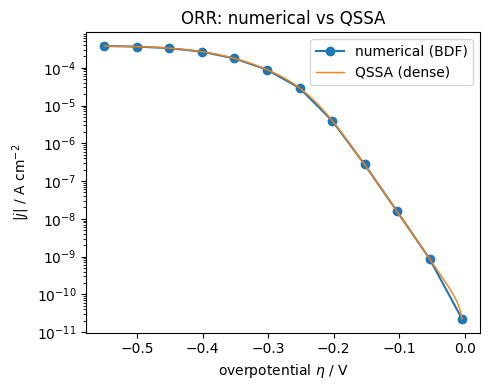

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_n, np.abs(j_n), "o-", label="numerical (BDF)")
ax.semilogy(eta_q, np.abs(j_q), "-", lw=1, label="QSSA (dense)")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("ORR: numerical vs QSSA")
fig.tight_layout(); plt.show()

## Stochastic simulation (Gillespie Monte Carlo)

With five surface species there are ten reaction channels. The underlying
methodology is unchanged. Note that the walkthrough case omits the $10^5$
non-RLS acceleration. With it, nearly every stochastic event would be a fast
step firing forward and backward, and the calculation budget would be spent on
channels that carry no net current.

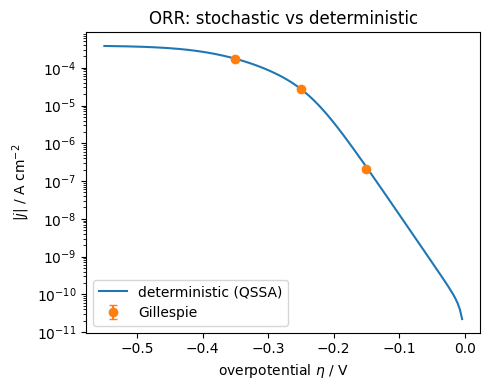

eta=-0.150 V   j=-2.066e-07 +/- 1.9e-08 A/cm^2
eta=-0.250 V   j=-2.778e-05 +/- 3.1e-07 A/cm^2
eta=-0.350 V   j=-1.733e-04 +/- 1.2e-07 A/cm^2


In [6]:
etas_gmc = np.array([-0.15, -0.25, -0.35])
eg, jg, seg, thg = core.gillespie_scan(mech, etas_gmc,
                                       n_sites=1000, n_burn=20000, n_prod=80000, n_traj=3)

fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_q, np.abs(j_q), "-", label="deterministic (QSSA)")
ax.errorbar(eg, np.abs(jg), yerr=seg, fmt="o", capsize=3, label="Gillespie")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("ORR: stochastic vs deterministic")
fig.tight_layout(); plt.show()

for e, jj, s in zip(eg, jg, seg):
    print(f"eta={e:+.3f} V   j={jj: .3e} +/- {s:.1e} A/cm^2")

## Potentiostatic transients

As with the earlier notebooks, we simulate a chronoamperometric experiment. The right panel
enlarges the early-time window. The transient code is provided so that this
behavior can be examined on any timescale.

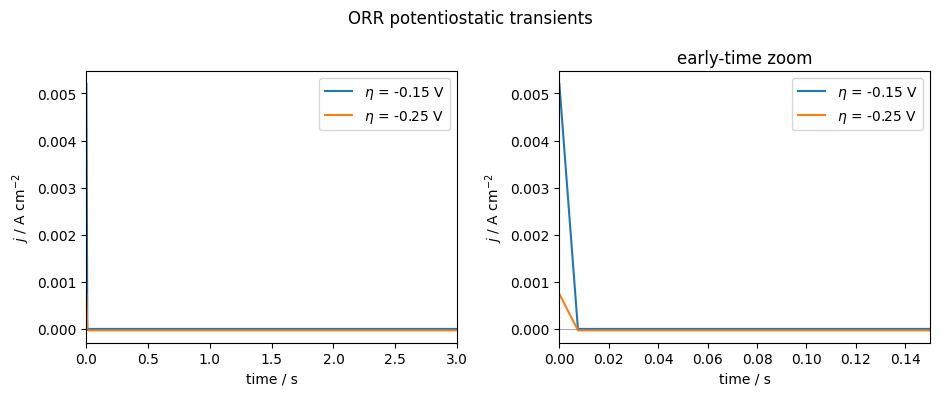

In [7]:
mech_fig = M.orr_case("PCET2")   # figure-exact variant (fast non-RLS steps)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for e in (-0.15, -0.25):
    t, it = core.transient(mech_fig, e, t_end=3.0, n=400)
    for ax in axes:
        ax.plot(t, it, label=fr"$\eta$ = {e:+.2f} V")
axes[0].set_xlim(0, 3.0); axes[1].set_xlim(0, 0.15)   # full window and zoom on the inversion
for ax in axes:
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("time / s"); ax.set_ylabel(r"$j$ / A cm$^{-2}$"); ax.legend()
axes[1].set_title("early-time zoom")
fig.suptitle("ORR potentiostatic transients")
fig.tight_layout(); plt.show()

## Five designed RLS cases

The fast non-RLS cases (`fast=1e5`), one per RLS. Near onset each case exhibits
its cardinal slope — saturating for ChemAds and approximately 120, 40, 24, and
17 mV/dec for PCET1–4 — because each electron transferred upstream of the RLS
steepens the coverage response. At larger $|\eta|$ the RLS reactant saturates
and every electron-transfer case relaxes toward 118 mV/dec, although the RLS
itself never changes. The slope varies with overpotential while the RLS does
not, and different RLS cases share the same high-overpotential slope.

In [8]:
cases = {name: core.qssa_scan(M.orr_case(name), etas_dense)
         for name in M.ORR_CASE_NAMES}

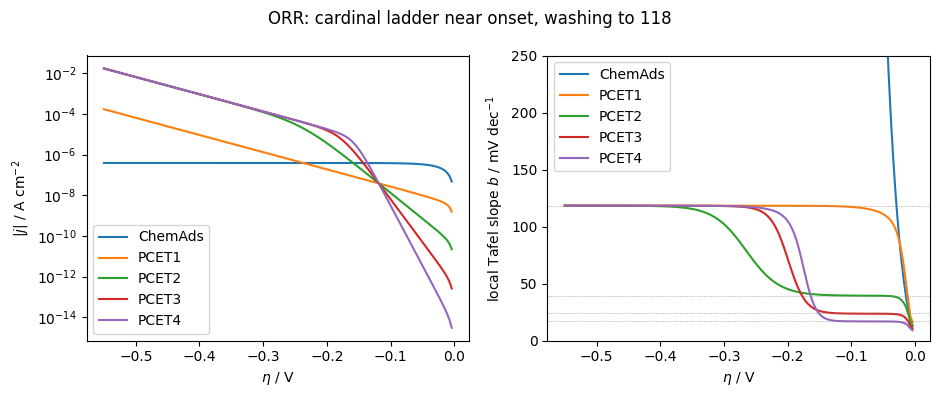

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
for name, (ee, jj, _, _) in cases.items():
    ax1.semilogy(ee, np.abs(jj), label=name)
    ax2.plot(ee, M.local_slope(ee, jj), label=name)
ax1.set_xlabel(r"$\eta$ / V"); ax1.set_ylabel(r"$|j|$ / A cm$^{-2}$"); ax1.legend()
ax2.set_xlabel(r"$\eta$ / V"); ax2.set_ylabel(r"local Tafel slope $b$ / mV dec$^{-1}$")
ax2.set_ylim(0, 250)
for bref in (118, 39, 24, 17):
    ax2.axhline(bref, color="gray", lw=0.5, ls=":")
ax2.legend(); fig.suptitle("ORR: cardinal slopes near onset, converging to 118")
fig.tight_layout(); plt.show()

In [10]:
def slope_at(ee, jj, eta0):
    b = M.local_slope(ee, jj)
    return b[np.argmin(np.abs(ee - eta0))]

print(f"{'case':>10}{'b @ -0.06 V':>14}{'b @ -0.50 V':>14}   (mV/dec)")
for name, (ee, jj, _, _) in cases.items():
    b1, b2 = slope_at(ee, jj, -0.06), slope_at(ee, jj, -0.50)
    fmt = lambda b: f"{b:10.1f}" if b < 1e3 else "     >1000"
    print(f"{name:>10}{fmt(b1):>14}{fmt(b2):>14}")

      case   b @ -0.06 V   b @ -0.50 V   (mV/dec)
   ChemAds         523.6         >1000
     PCET1         113.2         118.3
     PCET2          39.4         118.3
     PCET3          23.7         118.3
     PCET4          16.9         118.3


## Summary

The cardinal slope series is a property of an unsaturated RLS reactant
rather than a fingerprint of the RLS. In these cases the RLS is fixed by
construction across the entire scan, yet the observable slope traverses from
its cardinal value to $\approx 120$ mV/dec as the coverage saturates. The
mapping between slope and RLS is therefore not unique in either direction.
